# AI 221 Assignment 03: Linear and Logistic Regression

<b>Description:</b> This notebook demonstrates linear and logistic regression on the Wine Quality Dataset that can be found on https://archive.ics.uci.edu/dataset/186/wine+quality.

<b>Author:</b> Adrian Josele G. Quional
<br>
<b>Submitted to:</b> Dr. Jon Dewitt E. Dalisay
<br>
<b>Semester/Year:</b> 2nd Semester/2024-2025

## Imports

This section imports all needed Python libraries for the assignment.

In [1]:
# imports

# UCI repo
# Note: Before importing make sure to install first the UCI ML repo (if the dataset is not manually downloaded) using the command pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# numpy
import numpy as np

# for plotting
import matplotlib.pyplot as plt

# scikit-learn
from sklearn.preprocessing import StandardScaler, PolynomialFeatures # for standardizing feature columns and creating polynomial features
from sklearn.model_selection import train_test_split # for data splitting
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression # for fitting linear and logistic regression
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error, # metrics for evaluation of linear regression models
                            confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score) # metrics for evaluation of logistic regression models

## Data Processing

This section processes the data for linear and logistic regression model fitting.

### Fetching data

In [2]:
# fetching the wine quality dataset 
wine_quality = fetch_ucirepo(id=186) # alternatively: fetch_ucirepo(name='Wine Quality')

# saving the original (all features and target) data (as a pandas DataFrame) 
wine_quality_df = wine_quality.data.original
display(wine_quality_df)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


### Processing data

In [3]:
X_orig_df = wine_quality_df.drop(["quality", "color"], axis=1) # dropping target columns
print("Original feature DataFrame:")
display(X_orig_df)

X_orig_np = X_orig_df.to_numpy() # converting feature columns into NumPy array
print("NumPy array of original feature DataFrame:")
print(X_orig_np)

Original feature DataFrame:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


NumPy array of original feature DataFrame:
[[ 7.4   0.7   0.   ...  3.51  0.56  9.4 ]
 [ 7.8   0.88  0.   ...  3.2   0.68  9.8 ]
 [ 7.8   0.76  0.04 ...  3.26  0.65  9.8 ]
 ...
 [ 6.5   0.24  0.19 ...  2.99  0.46  9.4 ]
 [ 5.5   0.29  0.3  ...  3.34  0.38 12.8 ]
 [ 6.    0.21  0.38 ...  3.26  0.32 11.8 ]]


In [4]:
y_orig_qual_df = wine_quality_df[["quality"]] # getting only the target column for linear regression
print("Original wine quality target column:")
display(y_orig_qual_df)

y_orig_qual_np = y_orig_qual_df.to_numpy() # converting target column into NumPy array
print("NumPy array of wine quality target:")
print(y_orig_qual_np)

Original wine quality target column:


,quality
0,5
1,5
2,5
3,6
4,5
...,...
6492,6
6493,5
6494,6
6495,7


NumPy array of wine quality target:
[[5]
 [5]
 [5]
 ...
 [6]
 [7]
 [6]]


In [5]:
y_orig_color_df = wine_quality_df[["color"]] # getting only the target column for logistic regression
print("Original wine color target column:")
display(y_orig_color_df)

y_orig_color_df = y_orig_color_df.copy()

y_orig_color_df["is_red"] = y_orig_color_df["color"].map({"red": 1, "white": 0})
y_orig_color_df.drop("color", axis=1, inplace=True)
print("Binarized wine color target column:")
display(y_orig_color_df)

y_orig_color_np = y_orig_color_df.to_numpy() # converting target column into NumPy array
print("NumPy array of color target:")
print(y_orig_color_np)

Original wine color target column:


,color
0,red
1,red
2,red
3,red
4,red
...,...
6492,white
6493,white
6494,white
6495,white


Binarized wine color target column:


,is_red
0,1
1,1
2,1
3,1
4,1
...,...
6492,0
6493,0
6494,0
6495,0


NumPy array of color target:
[[1]
 [1]
 [1]
 ...
 [0]
 [0]
 [0]]


Standardizing and splitting the original data:

In [6]:
scaler = StandardScaler() # creating a scaler object
scaler.fit(X_orig_np) # calculating the mean and standard deviation for each feature
X_scaled = scaler.transform(X_orig_np) # applying the scaling to the data

# checking original vs. scaled data
print(f"Original data (X_orig): \n{X_orig_np}\n\n")
print(f"Scaled data (X_scaled): \n{X_scaled}")

Original data (X_orig): 
[[ 7.4   0.7   0.   ...  3.51  0.56  9.4 ]
 [ 7.8   0.88  0.   ...  3.2   0.68  9.8 ]
 [ 7.8   0.76  0.04 ...  3.26  0.65  9.8 ]
 ...
 [ 6.5   0.24  0.19 ...  2.99  0.46  9.4 ]
 [ 5.5   0.29  0.3  ...  3.34  0.38 12.8 ]
 [ 6.    0.21  0.38 ...  3.26  0.32 11.8 ]]


Scaled data (X_scaled): 
[[ 0.14247327  2.18883292 -2.19283252 ...  1.81308951  0.19309677
  -0.91546416]
 [ 0.45103572  3.28223494 -2.19283252 ... -0.11507303  0.99957862
  -0.58006813]
 [ 0.45103572  2.55330026 -1.91755268 ...  0.25811972  0.79795816
  -0.58006813]
 ...
 [-0.55179227 -0.6054167  -0.88525328 ... -1.42124765 -0.47897144
  -0.91546416]
 [-1.32319841 -0.30169391 -0.12823371 ...  0.75571005 -1.016626
   1.9354021 ]
 [-0.93749534 -0.78765037  0.42232597 ...  0.25811972 -1.41986693
   1.09691202]]


In [7]:
# splitting the data into training and test sets
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_scaled, y_orig_qual_np, test_size=0.30, random_state=221)

# checking the shapes of X
print(f"X_train_orig shape: {X_train_orig.shape}")
print(f"X_test_orig shape: {X_test_orig.shape}")
print()

# checking the shapes of y
print(f"y_train_orig shape: {y_train_orig.shape}")
print(f"y_test_orig shape: {y_test_orig.shape}")

X_train_orig shape: (4547, 11)
X_test_orig shape: (1950, 11)

y_train_orig shape: (4547, 1)
y_test_orig shape: (1950, 1)


Creating polynomial features, standardizing it, then splitting the data:

In [8]:
poly = PolynomialFeatures(degree=2) # creating a PolynomialFeatures object
X_poly = poly.fit_transform(X_orig_np)

scaler_poly = StandardScaler() # creating a new scaler object
scaler_poly.fit(X_poly) # calculating the mean and standard deviation for each feature
X_poly_scaled = scaler_poly.transform(X_poly) # applying the scaling to the data with polynomial features

# checking original vs. scaled data
print(f"Original data (X_orig): \n{X_orig_np}\n\n")
print(f"Scaled poly data (X_poly_scaled): \n{X_poly_scaled}")

Original data (X_orig): 
[[ 7.4   0.7   0.   ...  3.51  0.56  9.4 ]
 [ 7.8   0.88  0.   ...  3.2   0.68  9.8 ]
 [ 7.8   0.76  0.04 ...  3.26  0.65  9.8 ]
 ...
 [ 6.5   0.24  0.19 ...  2.99  0.46  9.4 ]
 [ 5.5   0.29  0.3  ...  3.34  0.38 12.8 ]
 [ 6.    0.21  0.38 ...  3.26  0.32 11.8 ]]


Scaled poly data (X_poly_scaled): 
[[ 0.          0.14247327  2.18883292 ...  0.0445424  -0.18215674
  -0.89431399]
 [ 0.          0.45103572  3.28223494 ...  0.76385416  0.64201955
  -0.59750051]
 [ 0.          0.45103572  2.55330026 ...  0.57097419  0.46894253
  -0.59750051]
 ...
 [ 0.         -0.55179227 -0.6054167  ... -0.44853421 -0.73553225
  -0.89431399]
 [ 0.         -1.32319841 -0.30169391 ... -0.77338468 -0.41763568
   2.02280606]
 [ 0.         -0.93749534 -0.78765037 ... -0.97641622 -1.0581384
   1.07207536]]


In [9]:
# splitting the data into training and test sets
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly_scaled, y_orig_qual_np, test_size=0.30, random_state=221)

# checking the shapes of X
print(f"X_train_poly shape: {X_train_poly.shape}")
print(f"X_test_poly shape: {X_test_poly.shape}")
print()

# checking the shapes of y
print(f"y_train_poly shape: {y_train_poly.shape}")
print(f"y_test_poly shape: {y_test_poly.shape}")

X_train_poly shape: (4547, 78)
X_test_poly shape: (1950, 78)

y_train_poly shape: (4547, 1)
y_test_poly shape: (1950, 1)


Creating features of second degree without interaction terms, standardizing it, and splitting the data:

In [10]:
X_orig_np_deg2 = np.hstack((X_orig_np, X_orig_np**2)) # creating features of the second degree without interaction terms
print("NumPy array of original feature DataFrame:")
print(X_orig_np)
print()

print("NumPy array with features of the second degree:")
print(X_orig_np_deg2)

NumPy array of original feature DataFrame:
[[ 7.4   0.7   0.   ...  3.51  0.56  9.4 ]
 [ 7.8   0.88  0.   ...  3.2   0.68  9.8 ]
 [ 7.8   0.76  0.04 ...  3.26  0.65  9.8 ]
 ...
 [ 6.5   0.24  0.19 ...  2.99  0.46  9.4 ]
 [ 5.5   0.29  0.3  ...  3.34  0.38 12.8 ]
 [ 6.    0.21  0.38 ...  3.26  0.32 11.8 ]]

NumPy array with features of the second degree:
[[7.40000e+00 7.00000e-01 0.00000e+00 ... 1.23201e+01 3.13600e-01
  8.83600e+01]
 [7.80000e+00 8.80000e-01 0.00000e+00 ... 1.02400e+01 4.62400e-01
  9.60400e+01]
 [7.80000e+00 7.60000e-01 4.00000e-02 ... 1.06276e+01 4.22500e-01
  9.60400e+01]
 ...
 [6.50000e+00 2.40000e-01 1.90000e-01 ... 8.94010e+00 2.11600e-01
  8.83600e+01]
 [5.50000e+00 2.90000e-01 3.00000e-01 ... 1.11556e+01 1.44400e-01
  1.63840e+02]
 [6.00000e+00 2.10000e-01 3.80000e-01 ... 1.06276e+01 1.02400e-01
  1.39240e+02]]


In [11]:
scaler_deg2 = StandardScaler() # creating a new scaler object
scaler_deg2.fit(X_orig_np_deg2) # calculating the mean and standard deviation for each feature
X_orig_np_deg2_scaled = scaler_deg2.transform(X_orig_np_deg2) # applying the scaling to the data of features of the second degree

# checking original vs. scaled data
print(f"Original data (X_orig): \n{X_orig_np}\n\n")
print(f"Scaled deg2 data (X_orig_np_deg2_scaled): \n{X_orig_np_deg2_scaled}")

Original data (X_orig): 
[[ 7.4   0.7   0.   ...  3.51  0.56  9.4 ]
 [ 7.8   0.88  0.   ...  3.2   0.68  9.8 ]
 [ 7.8   0.76  0.04 ...  3.26  0.65  9.8 ]
 ...
 [ 6.5   0.24  0.19 ...  2.99  0.46  9.4 ]
 [ 5.5   0.29  0.3  ...  3.34  0.38 12.8 ]
 [ 6.    0.21  0.38 ...  3.26  0.32 11.8 ]]


Scaled deg2 data (X_orig_np_deg2_scaled): 
[[ 0.14247327  2.18883292 -2.19283252 ...  1.85107036  0.0445424
  -0.89431399]
 [ 0.45103572  3.28223494 -2.19283252 ... -0.13828845  0.76385416
  -0.59750051]
 [ 0.45103572  2.55330026 -1.91755268 ...  0.23240309  0.57097419
  -0.59750051]
 ...
 [-0.55179227 -0.6054167  -0.88525328 ... -1.3814823  -0.44853421
  -0.89431399]
 [-1.32319841 -0.30169391 -0.12823371 ...  0.73736989 -0.77338468
   2.02280606]
 [-0.93749534 -0.78765037  0.42232597 ...  0.23240309 -0.97641622
   1.07207536]]


In [12]:
# splitting the data into training and test sets
X_train_deg2, X_test_deg2, y_train_deg2, y_test_deg2 = train_test_split(X_orig_np_deg2_scaled, y_orig_qual_np, test_size=0.30, random_state=221)

# checking the shapes of X
print(f"X_train_deg2 shape: {X_train_deg2.shape}")
print(f"X_test_deg2 shape: {X_test_deg2.shape}")
print()

# checking the shapes of y
print(f"y_train_deg2 shape: {y_train_deg2.shape}")
print(f"y_test_deg2 shape: {y_test_deg2.shape}")

X_train_deg2 shape: (4547, 22)
X_test_deg2 shape: (1950, 22)

y_train_deg2 shape: (4547, 1)
y_test_deg2 shape: (1950, 1)


Splitting data for logistic regression:

In [13]:
# data splitting for logistic regression
X_train_orig_logreg, X_test_orig_logreg, y_train_orig_logreg, y_test_orig_logreg = train_test_split(X_scaled, y_orig_color_np, test_size=0.30, random_state=221)

# checking the shapes of X
print(f"X_train_orig_logreg shape: {X_train_orig_logreg.shape}")
print(f"X_test_orig_logreg shape: {X_test_orig_logreg.shape}")
print()

# checking the shapes of y
print(f"y_train_orig_logreg shape: {y_train_orig_logreg.shape}")
print(f"y_test_orig_logreg shape: {y_test_orig_logreg.shape}")

X_train_orig_logreg shape: (4547, 11)
X_test_orig_logreg shape: (1950, 11)

y_train_orig_logreg shape: (4547, 1)
y_test_orig_logreg shape: (1950, 1)


## Linear Regression

This section presents various experiments to predict wine quality using linear regression.

### Experiment 1: Baseline linear regression model using all original features

Here, we fit a baseline model using all the features since this is the easiest to do. Based from this, we can conceptualize and implement further strategies to improve the prediction using only linear regression.

In [14]:
linreg_all_feat = LinearRegression() # creating a LinearRegression object
linreg_all_feat.fit(X_train_orig, y_train_orig) # fitting the model to the training data
y_pred_all_feat = linreg_all_feat.predict(X_test_orig) # making predictions on the test data
print("Predictions:")
print(y_pred_all_feat)

Predictions:
[[5.9369971 ]
 [6.25626218]
 [6.39927778]
 ...
 [6.54876991]
 [4.90301204]
 [5.07936069]]


In [15]:
# evaluating the model
score_all_feat = r2_score(y_test_orig, y_pred_all_feat) # getting r-squared
mse_all_feat = mean_squared_error(y_test_orig, y_pred_all_feat) # getting mse
mae_all_feat = mean_absolute_error(y_test_orig, y_pred_all_feat) # getting mae
print("EVALUATION FOR BASELINE LINEAR REGRESSION MODEL:\n")
print(f"R-squared: {score_all_feat}")
print(f"MSE: {mse_all_feat}")
print(f"MAE: {mae_all_feat}")
print()

# checking coefficients and intercept
print(f"Coefficients: {linreg_all_feat.coef_}")
print(f"Intercept: {linreg_all_feat.intercept_}")

EVALUATION FOR BASELINE LINEAR REGRESSION MODEL:

R-squared: 0.266081508945643
MSE: 0.5420717149690853
MAE: 0.5652056420268309

Coefficients: [[ 0.074422   -0.216534   -0.00789381  0.18665375 -0.02570002  0.13445194
  -0.14825617 -0.14559751  0.07395667  0.11648375  0.33072098]]
Intercept: [5.82249983]


As can be seen, just a regular linear regression using all features leads to an r-squared value of only 0.27. Let's see if this can be improved.

### Experiment 2: Linear regression models using each feature column 

Here, we fit a model using all features, one at a time. This is to check if using only one "best" feature improves the prediction. 

In [16]:
feature_names = list(X_orig_df.columns)
print(feature_names)

['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [17]:
# creating lists to store all evaluation metrics
r2s = []
mses = []
maes = []

print("EVALUATION FOR LINEAR REGRESSION USING ONE FEATURE AT A TIME: \n")

for feat in range(len(feature_names)):
    linreg_one_feat = LinearRegression() # creating a LinearRegression object
    linreg_one_feat.fit(X_train_orig[:, feat].reshape(-1, 1), y_train_orig) # fitting the model to the training data
    y_pred_one_feat = linreg_one_feat.predict(X_test_orig[:, feat].reshape(-1, 1)) # making predictions on the test data

    # evaluating the model / computing metrics
    score_one_feat = r2_score(y_test_orig, y_pred_one_feat) # getting r-squared
    mse_one_feat = mean_squared_error(y_test_orig, y_pred_one_feat) # getting mse
    mae_one_feat = mean_absolute_error(y_test_orig, y_pred_one_feat) # getting mae

    # appending all metrics to their corresponding lists
    r2s.append(score_one_feat)
    mses.append(mse_one_feat)
    maes.append(mae_one_feat)

    # viewing each metric
    print(f"Feature: {feature_names[feat]}")
    print(f"\tR-squared: {score_one_feat}")
    print(f"\tMSE: {mse_one_feat}")
    print(f"\tMAE: {mae_one_feat}")
    print()
    
    # checking coefficients and intercept
    print(f"\tCoefficients: {linreg_one_feat.coef_}")
    print(f"\tIntercept: {linreg_one_feat.intercept_}")
    print()

print()
print("====================")
r2s = np.array(r2s)
mses = np.array(mses)
maes = np.array(maes)

print(f"Max R-squared: {max(r2s)} (Feature: {feature_names[np.argmax(r2s)]})")
print(f"Min MSE: {min(mses)}  (Feature: {feature_names[np.argmin(mses)]})")
print(f"Min MAE: {min(maes)} (Feature: {feature_names[np.argmin(maes)]})")

EVALUATION FOR LINEAR REGRESSION USING ONE FEATURE AT A TIME: 

Feature: fixed_acidity
	R-squared: 0.0022888463012673554
	MSE: 0.7369088021645179
	MAE: 0.6757959587968743

	Coefficients: [[-0.07329106]]
	Intercept: [5.82272968]

Feature: volatile_acidity
	R-squared: 0.07144027465469516
	MSE: 0.6858336026471261
	MAE: 0.6292315229669821

	Coefficients: [[-0.2315892]]
	Intercept: [5.82436569]

Feature: citric_acid
	R-squared: 0.007665607857640033
	MSE: 0.7329375296139985
	MAE: 0.6754699945049759

	Coefficients: [[0.07417401]]
	Intercept: [5.82300243]

Feature: residual_sugar
	R-squared: 0.0005296639838964223
	MSE: 0.7382081330675322
	MAE: 0.6793091727641487

	Coefficients: [[-0.03475406]]
	Intercept: [5.82294512]

Feature: chlorides
	R-squared: 0.03949533023215568
	MSE: 0.7094281175950204
	MAE: 0.6546846030214037

	Coefficients: [[-0.17180426]]
	Intercept: [5.82368515]

Feature: free_sulfur_dioxide
	R-squared: -0.004373483140325485
	MSE: 0.7418295943098486
	MAE: 0.6780770578698188

	Coeff

The results show that `alcohol` indeed best predicts wine quality.

### Experiment 3: Linear regression model using all polynomial features

Here, we try to fit a linear regression model using polynomial features for all features, to check if having a more expressive model can improve the prediction.

In [18]:
linreg_poly_all_feat = LinearRegression() # creating a new LinearRegression object
linreg_poly_all_feat.fit(X_train_poly, y_train_poly) # fitting the model to the training data
y_pred_poly_all_feat = linreg_poly_all_feat.predict(X_test_poly) # making predictions on the test data
print("Predictions:")
print(y_pred_poly_all_feat)

Predictions:
[[6.05822262]
 [6.24168216]
 [6.69043809]
 ...
 [6.79760411]
 [4.81572501]
 [4.97419057]]


In [19]:
score_poly_all_feat = r2_score(y_test_poly, y_pred_poly_all_feat) # getting r-squared
mse_poly_all_feat = mean_squared_error(y_test_poly, y_pred_poly_all_feat) # getting mse
mae_poly_all_feat = mean_absolute_error(y_test_poly, y_pred_poly_all_feat) # getting mae
print("EVALUATION FOR LINEAR REGRESSION USING ALL POLYNOMIAL FEATURES: \n")
print(f"R-squared: {score_poly_all_feat}")
print(f"MSE: {mse_poly_all_feat}")
print(f"MAE: {mae_poly_all_feat}")
print()

# checking coefficients and intercept
print(f"Coefficients: {linreg_poly_all_feat.coef_}")
print(f"Intercept: {linreg_poly_all_feat.intercept_}")

EVALUATION FOR LINEAR REGRESSION USING ALL POLYNOMIAL FEATURES: 

R-squared: 0.3261877375894564
MSE: 0.49767729401033783
MAE: 0.5430265082286676

Coefficients: [[ 1.32363697e-11 -8.40302674e+01 -2.37497973e+01  6.17156723e+01
  -1.50723387e+02 -4.47303228e+01  1.97403093e+01  8.19133637e+01
   1.04509393e+02  2.60324815e+01 -2.52148957e+01  6.28418693e+01
  -1.68737875e+00 -1.51612729e-02  9.47529969e-01 -1.22280365e+00
  -7.39134489e-01  1.95825441e-01  8.84970071e-02  8.58607724e+01
  -1.96894329e-01 -8.17134345e-02  9.57918582e-01  3.30941229e-02
  -1.03516989e-02 -2.70751861e-01  1.01929823e-01  2.97935985e-02
   1.03379491e-01  2.31570069e+01 -3.86059637e-01 -5.74210854e-03
   7.92564415e-01 -1.46227670e-01  2.81669798e-01  1.27333217e-01
   9.70767228e-02 -3.97728417e-02 -6.31152088e+01  1.00464365e+00
   1.66725952e-02 -5.36157034e-01 -1.14360936e+00 -2.63721759e-01
   4.87762440e-02  5.29410700e-01  1.53281023e+02 -1.19273831e+00
  -3.50195656e-01  1.72221260e+00 -4.92806972e-0

Even with polynomial features, the model improved only slightly, having a new $r^2$ of 0.33.

### Experiment 4: Linear regression using all features of the second degree (no interaction)

Here, we try to fit a linear regression model using handcrafted features of the second degree (no interaction terms).

In [20]:
linreg_deg2_all_feat = LinearRegression() # creating a new LinearRegression object
linreg_deg2_all_feat.fit(X_train_deg2, y_train_deg2) # fitting the model to the training data
y_pred_deg2_all_feat = linreg_deg2_all_feat.predict(X_test_deg2) # making predictions on the test data
print("Predictions:")
print(y_pred_deg2_all_feat)

Predictions:
[[5.92415046]
 [6.27729485]
 [6.49816664]
 ...
 [6.62070066]
 [4.94443442]
 [5.16623569]]


In [21]:
print("EVALUATION FOR LINEAR REGRESSION USING ALL FEATURES OF THE SECOND DEGREE (NO INTERACTION TERMS): \n")
score_deg2_all_feat = r2_score(y_test_deg2, y_pred_deg2_all_feat) # getting r-squared
mse_deg2_all_feat = mean_squared_error(y_test_deg2, y_pred_deg2_all_feat) # getting mse
mae_deg2_all_feat = mean_absolute_error(y_test_deg2, y_pred_deg2_all_feat) # getting mae
print(f"R-squared: {score_deg2_all_feat}")
print(f"MSE: {mse_deg2_all_feat}")
print(f"MAE: {mae_deg2_all_feat}")
print()

# checking coefficients and intercept
print(f"Coefficients: {linreg_deg2_all_feat.coef_}")
print(f"Intercept: {linreg_deg2_all_feat.intercept_}")

EVALUATION FOR LINEAR REGRESSION USING ALL FEATURES OF THE SECOND DEGREE (NO INTERACTION TERMS): 

R-squared: 0.2699125008203671
MSE: 0.5392421468891464
MAE: 0.5600550155936159

Coefficients: [[ 1.85405443e-01 -2.63178011e-01  5.67568152e-02  3.59601957e-01
   3.96457541e-03  4.11971576e-01 -2.50418476e-01 -2.76891970e+01
   6.74934723e-01  2.03253498e-01 -1.50327700e-01 -1.16107415e-01
   5.04695315e-02 -6.96774542e-02 -2.28339614e-01 -1.99798777e-02
  -3.38188807e-01  5.71828563e-02  2.75459579e+01 -6.01894994e-01
  -8.04760084e-02  4.46973170e-01]]
Intercept: [5.81961805]


As can be seen, the results didn't improve much compared to that of using all original features ($r^2$ of also about 0.27).

### Experiment 5: Linear regression using each polynomial feature

Here, we try to fit multiple linear regression models using each polynomial feature, one at a time. This is to see if one polynomial feature stands out to improve the model.

In [22]:
# creating lists to store all evaluation metrics
r2s_poly = []
mses_poly = []
maes_poly = []
cols = []

print("EVALUATION FOR LINEAR REGRESSION USING ONE POLYNOMIAL FEATURE AT A TIME: \n")

# iterate through all columns of the X_poly_scaled array
for col in range(X_poly_scaled.shape[1]):
    linreg_poly_one_feat = LinearRegression() # creating a new LinearRegression object foe each polynomial feature column
    linreg_poly_one_feat.fit(X_train_poly[:, col].reshape(-1, 1), y_train_poly) # fitting the model to the training data
    y_pred_poly_one_feat = linreg_poly_one_feat.predict(X_test_poly[:, col].reshape(-1, 1)) # making predictions on the test data

    # evaluating the model / computing metrics
    score_poly_one_feat = r2_score(y_test_poly, y_pred_poly_one_feat) # getting r-squared
    mse_poly_one_feat = mean_squared_error(y_test_poly, y_pred_poly_one_feat) # getting mse
    mae_poly_one_feat = mean_absolute_error(y_test_poly, y_pred_poly_one_feat) # getting mae
    
    # appending all metrics to their corresponding lists
    r2s_poly.append(score_poly_one_feat)
    mses_poly.append(mse_poly_one_feat)
    maes_poly.append(mae_poly_one_feat)

    # viewing each metric
    print(f"Feature: Column {col}")
    cols.append(col)
    print(f"\tR-squared: {score_poly_one_feat}")
    print(f"\tMSE: {mse_poly_one_feat}")
    print(f"\tMAE: {mae_poly_one_feat}")
    print()
    
    # checking coefficients and intercept
    # uncomment to see verbose output
    # print(f"\tCoefficients: {linreg_poly_one_feat.coef_}")     
    # print(f"\tIntercept: {linreg_poly_one_feat.intercept_}")
    # print()

print()
print("====================")
r2s_poly = np.array(r2s_poly)
mses_poly = np.array(mses_poly)
maes_poly = np.array(maes_poly)

print(f"Max R-squared: {max(r2s_poly)} (Feature: Column {cols[np.argmax(r2s_poly)]})")
print(f"Min MSE: {min(mses_poly)}  (Feature: Column {cols[np.argmin(mses_poly)]})")
print(f"Min MAE: {min(maes_poly)} (Feature: Column {cols[np.argmin(maes_poly)]})")

EVALUATION FOR LINEAR REGRESSION USING ONE POLYNOMIAL FEATURE AT A TIME: 

Feature: Column 0
	R-squared: -0.0002860418168078027
	MSE: 0.7388106128356366
	MAE: 0.6801412032729385

Feature: Column 1
	R-squared: 0.0022888463012673554
	MSE: 0.7369088021645179
	MAE: 0.6757959587968743

Feature: Column 2
	R-squared: 0.07144027465469516
	MSE: 0.6858336026471261
	MAE: 0.629231522966982

Feature: Column 3
	R-squared: 0.007665607857640033
	MSE: 0.7329375296139985
	MAE: 0.6754699945049759

Feature: Column 4
	R-squared: 0.0005296639838964223
	MSE: 0.7382081330675322
	MAE: 0.6793091727641487

Feature: Column 5
	R-squared: 0.03949533023215546
	MSE: 0.7094281175950206
	MAE: 0.6546846030214037

Feature: Column 6
	R-squared: -0.004373483140325485
	MSE: 0.7418295943098486
	MAE: 0.6780770578698188

Feature: Column 7
	R-squared: 0.0026167563529662097
	MSE: 0.7366666080159217
	MAE: 0.6785695166116947

Feature: Column 8
	R-squared: 0.09017946719698378
	MSE: 0.6719928473557024
	MAE: 0.6483795657466495

Featu

This shows that most of the polynomial features doesn't improve the prediction - in fact, they worsen the performance. The Column 77 feature corresponds to a polynomial feature involving the same `alcohol` column, which really shows that the feature is really a good predictor of wine quality. However, converting it into a polynomial feature didn't improve the model. 

### Experiment 6: Linear regression using all original features with L2 regularization (Ridge Regression)

Here, we use all original (standardized) features but we use Ridge Regression to automatically penalize features that don't contribute to improving the model's performance.

In [23]:
# creating lists to store all evaluation metrics
r2s_orig_ridge = []
mses_orig_ridge = []
maes_orig_ridge = []
alphas = []

print("EVALUATION FOR LINEAR REGRESSION USING ALL ORIGINAL FEATURES AND RIDGE REGRESSION: \n")

# searching for the best linear regression model by varying the L2 parameter
for alpha in np.array([0, 0.1, 0.5, 1, 5, 10, 50, 100]):
    ridge_reg_model_orig = Ridge(alpha=alpha)
    ridge_reg_model_orig.fit(X_train_orig, y_train_orig)
    y_pred_ridge_orig = ridge_reg_model_orig.predict(X_test_orig)
    
    print(f"Alpha: {alpha}")
    alphas.append(alpha)
    
    # evaluating the model / computing metrics
    score_orig_ridge = r2_score(y_test_orig, y_pred_ridge_orig)
    mse_orig_ridge = mean_squared_error(y_test_orig, y_pred_ridge_orig) # getting mse
    mae_orig_ridge = mean_absolute_error(y_test_orig, y_pred_ridge_orig) # getting mae

    # appending all metrics to their corresponding lists
    r2s_orig_ridge.append(score_orig_ridge)
    mses_orig_ridge.append(mse_orig_ridge)
    maes_orig_ridge.append(mae_orig_ridge)

    # viewing each metric
    print(f"\tR-squared: {score_orig_ridge}")
    print(f"\tMSE: {mse_orig_ridge}")
    print(f"\tMAE: {mae_orig_ridge}")
    print()
    
    # checking coefficients and intercept
    # uncomment to see verbose output
    # print(f"\tCoefficients: {ridge_reg_model.coef_}")
    # print(f"\tIntercept: {ridge_reg_model.intercept_}")
    # print()

print("====================")
r2s_orig_ridge = np.array(r2s_orig_ridge)
mses_orig_ridge = np.array(mses_orig_ridge)
maes_orig_ridge = np.array(maes_orig_ridge)
alphas = np.array(alphas)

print(f"Max R-squared: {max(r2s_orig_ridge)} (Alpha: {alphas[np.argmax(r2s_orig_ridge)]})")
print(f"Min MSE: {min(mses_orig_ridge)}  (Alpha: {alphas[np.argmin(mses_orig_ridge)]})")
print(f"Min MAE: {min(maes_orig_ridge)} (Alpha: {alphas[np.argmin(maes_orig_ridge)]})")

EVALUATION FOR LINEAR REGRESSION USING ALL ORIGINAL FEATURES AND RIDGE REGRESSION: 

Alpha: 0.0
	R-squared: 0.26608150894564264
	MSE: 0.5420717149690856
	MAE: 0.565205642026831

Alpha: 0.1
	R-squared: 0.2660818654075968
	MSE: 0.5420714516865206
	MAE: 0.56520624045869

Alpha: 0.5
	R-squared: 0.26608328842749696
	MSE: 0.5420704006449579
	MAE: 0.5652086303681284

Alpha: 1.0
	R-squared: 0.2660850608599866
	MSE: 0.5420690915274864
	MAE: 0.5652116092139791

Alpha: 5.0
	R-squared: 0.266098990192867
	MSE: 0.5420588033313789
	MAE: 0.5652351077532731

Alpha: 10.0
	R-squared: 0.26611579013239584
	MSE: 0.5420463949070883
	MAE: 0.5652638290215651

Alpha: 50.0
	R-squared: 0.26622630239460954
	MSE: 0.5419647706228748
	MAE: 0.5654789570319745

Alpha: 100.0
	R-squared: 0.2663005976439151
	MSE: 0.5419098962005842
	MAE: 0.5657298996398649

Max R-squared: 0.2663005976439151 (Alpha: 100.0)
Min MSE: 0.5419098962005842  (Alpha: 100.0)
Min MAE: 0.565205642026831 (Alpha: 0.0)


This shows that a Ridge Regression parameter of 100 leads to the highest $r^2$; however, if all r-squared values are looked closely, the different Ridge Regression parameter don't have much of a different among one another.

### Experiment 7: Linear regression using all polynomial features with L2 regularization (Ridge Regression)

Here, we try Ridge Regression which implements L2 regularization, penalizing features that don't contribute to enhancing the model's performance. We use this to all polynomial features. 

In [24]:
# creating lists to store all evaluation metrics
r2s_poly_ridge = []
mses_poly_ridge = []
maes_poly_ridge = []
alphas = []

print("EVALUATION FOR LINEAR REGRESSION USING ALL POLYNOMIAL FEATURES AND RIDGE REGRESSION: \n")

# searching for the best linear regression model by varying the L2 parameter
for alpha in np.array([0, 0.1, 0.5, 1, 5, 10, 50, 100]):
    ridge_reg_model_poly = Ridge(alpha=alpha)
    ridge_reg_model_poly.fit(X_train_poly, y_train_poly)
    y_pred_ridge_poly = ridge_reg_model_poly.predict(X_test_poly)
    
    print(f"Alpha: {alpha}")
    alphas.append(alpha)
    
    # evaluating the model / computing metrics
    score_poly_ridge = r2_score(y_test_poly, y_pred_ridge_poly)
    mse_poly_ridge = mean_squared_error(y_test_poly, y_pred_ridge_poly) # getting mse
    mae_poly_ridge = mean_absolute_error(y_test_poly, y_pred_ridge_poly) # getting mae

    # appending all metrics to their corresponding lists
    r2s_poly_ridge.append(score_poly_ridge)
    mses_poly_ridge.append(mse_poly_ridge)
    maes_poly_ridge.append(mae_poly_ridge)

    # viewing each metric
    print(f"\tR-squared: {score_poly_ridge}")
    print(f"\tMSE: {mse_poly_ridge}")
    print(f"\tMAE: {mae_poly_ridge}")
    print()
    
    # checking coefficients and intercept
    # uncomment to see verbose output
    # print(f"\tCoefficients: {ridge_reg_model.coef_}")
    # print(f"\tIntercept: {ridge_reg_model.intercept_}")
    # print()

print("====================")
r2s_poly_ridge = np.array(r2s_poly_ridge)
mses_poly_ridge = np.array(mses_poly_ridge)
maes_poly_ridge = np.array(maes_poly_ridge)
alphas = np.array(alphas)

print(f"Max R-squared: {max(r2s_poly_ridge)} (Alpha: {np.argmax(r2s_poly_ridge)})")
print(f"Min MSE: {min(mses_poly_ridge)}  (Alpha: {np.argmin(mses_poly_ridge)})")
print(f"Min MAE: {min(maes_poly_ridge)} (Alpha: {np.argmin(maes_poly_ridge)})")

EVALUATION FOR LINEAR REGRESSION USING ALL POLYNOMIAL FEATURES AND RIDGE REGRESSION: 

Alpha: 0.0
	R-squared: 0.32565045937193005
	MSE: 0.49807412734856266
	MAE: 0.5429673768516046

Alpha: 0.1
	R-squared: 0.3190349656902095
	MSE: 0.5029603266324445
	MAE: 0.5486673012094622

Alpha: 0.5
	R-squared: 0.3173952088674231
	MSE: 0.5041714499436764
	MAE: 0.5490531404613261

Alpha: 1.0
	R-squared: 0.3166597142359038
	MSE: 0.5047146857949566
	MAE: 0.5491628389561134

Alpha: 5.0
	R-squared: 0.31483472029193416
	MSE: 0.5060626251221081
	MAE: 0.5496590198148307

Alpha: 10.0
	R-squared: 0.31421453257185716
	MSE: 0.5065206953644069
	MAE: 0.5500161033885602

Alpha: 50.0
	R-squared: 0.31494170233777496
	MSE: 0.5059836082533867
	MAE: 0.5511997955931581

Alpha: 100.0
	R-squared: 0.31525974662550404
	MSE: 0.5057487009515721
	MAE: 0.5521381395071662

Max R-squared: 0.32565045937193005 (Alpha: 0)
Min MSE: 0.49807412734856266  (Alpha: 0)
Min MAE: 0.5429673768516046 (Alpha: 0)


This shows that even though we didn't use Ridge Regression (parameter of 0), we still got the "best" $r^2$ so far: about 0.33.

### Experiment 8: Linear regression using all features of the second degree with L2 regularization (Ridge Regression)

Here, we use the same process as before: use all features then use Ridge Regression to automatically penalize features that don't contribute to improving the model's performance. However, this time, we use all features of the second degree.

In [25]:
# creating lists to store all evaluation metrics
r2s_deg2_ridge = []
mses_deg2_ridge = []
maes_deg2_ridge = []
alphas = []

print("EVALUATION FOR LINEAR REGRESSION USING ALL FEATURES OF THE SECOND DEGREE AND RIDGE REGRESSION: \n")

# searching for the best linear regression model by varying the L2 parameter
for alpha in np.array([0, 0.1, 0.5, 1, 5, 10, 50, 100]):
    ridge_reg_model_deg2 = Ridge(alpha=alpha)
    ridge_reg_model_deg2.fit(X_train_deg2, y_train_deg2)
    y_pred_ridge_deg2 = ridge_reg_model_deg2.predict(X_test_deg2)
    
    print(f"Alpha: {alpha}")
    alphas.append(alpha)
    
    # evaluating the model / computing metrics
    score_deg2_ridge = r2_score(y_test_deg2, y_pred_ridge_deg2)
    mse_deg2_ridge = mean_squared_error(y_test_deg2, y_pred_ridge_deg2) # getting mse
    mae_deg2_ridge = mean_absolute_error(y_test_deg2, y_pred_ridge_deg2) # getting mae

    # appending all metrics to their corresponding lists
    r2s_deg2_ridge.append(score_deg2_ridge)
    mses_deg2_ridge.append(mse_deg2_ridge)
    maes_deg2_ridge.append(mae_deg2_ridge)

    # viewing each metric
    print(f"\tR-squared: {score_deg2_ridge}")
    print(f"\tMSE: {mse_deg2_ridge}")
    print(f"\tMAE: {mae_deg2_ridge}")
    print()
    
    # checking coefficients and intercept
    # uncomment to see verbose output
    # print(f"\tCoefficients: {ridge_reg_model_deg2.coef_}")
    # print(f"\tIntercept: {ridge_reg_model_deg2.intercept_}")
    # print()

print("====================")
r2s_deg2_ridge = np.array(r2s_poly_ridge)
mses_deg2_ridge = np.array(mses_poly_ridge)
maes_deg2_ridge = np.array(maes_poly_ridge)
alphas = np.array(alphas)

print(f"Max R-squared: {max(r2s_deg2_ridge)} (Alpha: {np.argmax(r2s_deg2_ridge)})")
print(f"Min MSE: {min(mses_deg2_ridge)}  (Alpha: {np.argmin(mses_deg2_ridge)})")
print(f"Min MAE: {min(maes_deg2_ridge)} (Alpha: {np.argmin(maes_deg2_ridge)})")

EVALUATION FOR LINEAR REGRESSION USING ALL FEATURES OF THE SECOND DEGREE AND RIDGE REGRESSION: 

Alpha: 0.0
	R-squared: 0.26991250082030616
	MSE: 0.5392421468891914
	MAE: 0.5600550155936577

Alpha: 0.1
	R-squared: 0.2683962745411781
	MSE: 0.540362030622094
	MAE: 0.5600085383814887

Alpha: 0.5
	R-squared: 0.26853489174561906
	MSE: 0.5402596480460294
	MAE: 0.5600215939330381

Alpha: 1.0
	R-squared: 0.26891848168490384
	MSE: 0.5399763287690695
	MAE: 0.5600131841746567

Alpha: 5.0
	R-squared: 0.27174248830993986
	MSE: 0.5378905193324957
	MAE: 0.560215728863143

Alpha: 10.0
	R-squared: 0.2749520983034518
	MSE: 0.5355199035014849
	MAE: 0.5604661908910786

Alpha: 50.0
	R-squared: 0.28915383599417466
	MSE: 0.5250305093802227
	MAE: 0.561318848226956

Alpha: 100.0
	R-squared: 0.2932013535050625
	MSE: 0.5220410156077707
	MAE: 0.5619652423065287

Max R-squared: 0.32565045937193005 (Alpha: 0)
Min MSE: 0.49807412734856266  (Alpha: 0)
Min MAE: 0.5429673768516046 (Alpha: 0)


This shows that even though we didn't use Ridge Regression (parameter of 0), we still got the "best" $r^2$ so far: about 0.33.

### Summary:

For linear regression, there are several experiments conducted; however, across all experiments, the performance of the model didn't improve much. In this regard, the best $r^2$ obtained so far is only about 0.33. Shown in the table below is the summary of $r^2$ values across all experiments:

| Experiment | Best $r^2$ |
| --- | --- |
| Using all original features | 0.266081508945643 |
| Using only alcohol feature | 0.1875348082282816 |
| Using all polynomial features | 0.3261877375894564 |
| Using all second-degree features (no interaction) | 0.2699125008203671 |
| Using one polynomial feature (associated with alcohol) | 0.1910328432291205 |
| Using all original features - Ridge Regression (parameter: 100) | 0.2663005976439151 |
| Using all polynomial features - Ridge Regression (parameter: 0) | 0.32565045937193005 |
| Using all second-degree features - Ridge Regression (parameter: 0) | 0.32565045937193005 |

Insights:
* Across all experiments, using all polynomial features leads to the "best" result; however, this is perhaps not the best that can be achieved via linear regression. To improve this, perhaps extensive feature engineering must be employed. This feature engineering must focus on the `alcohol` content, since based on EDA and previous linear regression results, `alcohol` contributed much on the results.
* Feature selection, and extensive engineering on those features, may improve the result.
* Perhaps linear regression is not the ideal model to use for wine quality prediction. There may be some non-linearity involved which is difficult to be captured by linear regression.
* The low $r^2$ may be due to the data itself: it is highly-imbalanced and the wine quality values are discrete. In this regard, perhaps the problem can be best viewed as a classification problem rather than as a regression problem.
* There are numerous implementions of wine quality prediction on the same dataset, and so far, the $r^2$ presented is within the range of 0.2 to 0.4. Considering this, the obtained $r^2$ values in the experiments safely falls into this reported range. Moreover, a published literature (<a href="https://www.sciencedirect.com/science/article/pii/S1877050917328053">"Selection of important features and predicting wine quality using machine learning techniques"</a> by Yogesh Gupta) reported an $r^2$ of 0.36055170 when linear regression on the quality of red wine is conducted, while an $r^2$ of 0.30675369 for linear regression on the quality of white wine. This literature further supports the $r^2$ values obtained in this assignment's experiments.

## Logistic Regression

This section presents an attempt to predict wine color using logistic regression.

In [26]:
# checking how many red and white wines in the test set
print(np.unique(y_test_orig_logreg, return_counts=True))

(array([0, 1]), array([1465,  485]))


Thus, there are 1465 white wines and 485 red wines.

Accuracy: 0.993842093688146
Coefficients: (array([-5.10366581]), array([[ 0.10011399,  1.1975537 , -0.49306096, -5.32601616,  0.84232718,
         1.19662895, -3.17737114,  4.89903479,  0.09702451,  0.68349164,
         1.79250974]]))


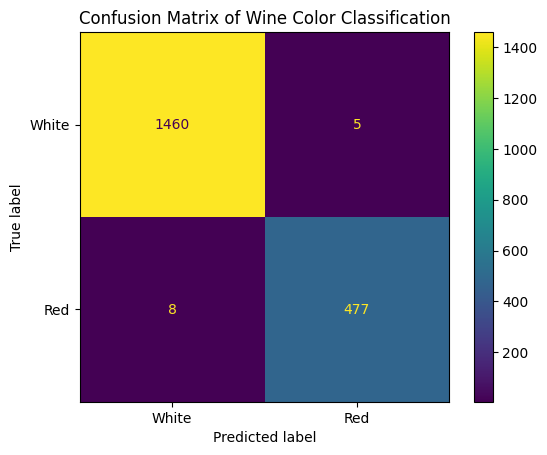

In [27]:
y_train_orig_logreg = y_train_orig_logreg.ravel()

logreg_model_all_feat = LogisticRegression(solver="newton-cg", random_state=221, penalty=None) # creating a LogisticRegression object
logreg_model_all_feat.fit(X_train_orig_logreg, y_train_orig_logreg) # fitting the model
y_pred_logreg_all_feat = logreg_model_all_feat.predict(X_test_orig_logreg)  # using the fitted model to predict on the test set

# evaluating the model
print(f"Accuracy: {logreg_model_all_feat.score(X_train_orig_logreg, y_train_orig_logreg)}")
print(f"Coefficients: {logreg_model_all_feat.intercept_, logreg_model_all_feat.coef_}")

cfm = confusion_matrix(y_test_orig_logreg, y_pred_logreg_all_feat)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cfm, display_labels = ["White", "Red"])
cm_display.plot()
plt.title("Confusion Matrix of Wine Color Classification")
plt.show()

AUC: 0.9924731712466135


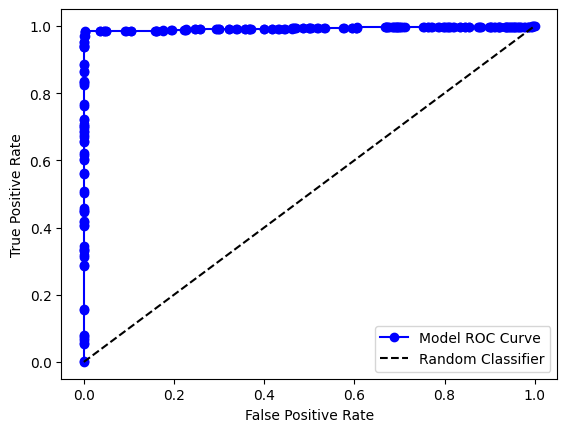

In [28]:
y_pred_logreg_all_feat_2 = logreg_model_all_feat.predict_proba(X_test_orig_logreg)

fpr, tpr, thresholds = roc_curve(y_test_orig_logreg, y_pred_logreg_all_feat_2[:, 1])
print(f"AUC: {roc_auc_score(y_test_orig_logreg, y_pred_logreg_all_feat_2[:, 1])}")

plt.plot(fpr, tpr, 'b-o', label="Model ROC Curve")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Summary:

* Using all original features leads already to a good result. Based on the confusion matrix, there are only a few misclassifications.
* However, it is suggested that a more intensive analysis should be conducted in order to verify if the logistic regression model really lead to the best result.
* On the other hand, since logistic regression involves a non-linear function which leads to a "good" result, this may suggest that in order to predict on the wine dataset, some non-linearity must be employed. 